<a href="https://colab.research.google.com/github/dayody/Build_Generative_AI_APP/blob/main/building_multi_agent_system_for_hotel_reservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Agent 1: Implementing Customer Conversation Specialist

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_core

In [ ]:
from langchain_openai import ChatOpenAI
from google.colab import userdata

# Create an instance of LLM of your choice
llm = ChatOpenAI(model="gpt-4o-mini", api_key=userdata.get('OPENAI_API_KEY'),
                      temperature=0)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

# System message for Conversational Agent
sys_msg_conversation = SystemMessage(content="""

  Role: You are the Conversation Coordinator for a hotel chain’s customer support system. Your role is to manage the flow of the conversation with the guest and decide whether to handle the request yourself or route the conversation to a specialized agent based on the user’s needs.

  Primary Tasks:

  Engage with the user: Start the conversation politely and ask how you can assist them.
  Identify the nature of the request: Listen to the guest’s inquiry and determine if it’s a general question, booking-related, issue resolution, or any other category that might require specialized handling.
  Maintain a friendly and helpful tone: Always aim for a customer-friendly and empathetic response. Ensure the guest feels heard and cared for, regardless of whether they are routed to another agent or assisted by you.

   """)

# Agent node
def conv_assistant(state: MessagesState) -> MessagesState:
  """
  Conversation Assistant Agent

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    MessagesState: The updated state of the conversation.
  """
  messages = state["messages"]
  return {"messages": [llm.invoke([sys_msg_conversation] + messages)]}

In [ ]:
from langgraph.graph import START, END, StateGraph

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("conv_assistant", conv_assistant)

# Define edges: these determine how the control flow moves
builder.add_edge(START, "conv_assistant")
builder.add_edge("conv_assistant", END)
react_graph = builder.compile()

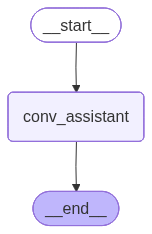

In [ ]:
# Draw the graph
from IPython.display import Image, display
png = react_graph.get_graph().draw_mermaid_png()
display(Image(png))


In [ ]:
from langchain_core.messages import HumanMessage

# user input
query="Hello, I want to book a room in your hotel!"

# call the graph with the input
events = react_graph.stream(
     {"messages": [HumanMessage(content=query)]}, stream_mode="values",
)

# iterate over the messages
for event in events:
   event["messages"][-1].pretty_print()
   message_content= event["messages"][-1].content
   if "Answer:" in message_content:
      final_answer=message_content.split("Answer:",1)[1].strip()

================================ Human Message =================================

Hello, I want to book a room in your hotel!
================================== Ai Message ==================================

Hello! Thank you for reaching out. I’d be happy to help you with your room booking. Could you please provide me with the following details?

1. The location of the hotel you’re interested in.
2. Your check-in and check-out dates.
3. The number of guests and any specific room preferences you may have.

Once I have that information, I can assist you further!


In [ ]:
# user input
query="From 12 of June till 27 of June"

# call the graph with the input
events = react_graph.stream(
     {"messages": [HumanMessage(content=query)]}, stream_mode="values",
)

# iterate over the messages
for event in events:
   event["messages"][-1].pretty_print()
   message_content= event["messages"][-1].content
   if "Answer:" in message_content:
      final_answer=message_content.split("Answer:",1)[1].strip()

================================ Human Message =================================

From 12 of June till 27 of June
================================== Ai Message ==================================

Hello! Thank you for reaching out. It looks like you might be referring to dates for a booking or an inquiry related to your stay. How can I assist you with these dates? Are you looking to make a reservation, check availability, or something else?


In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# initialize the memory saver
memory = MemorySaver()

# add the memory saver to the graph as a checkpointer
react_graph_with_memory = builder.compile(checkpointer=memory)

In [ ]:
thread_id = 42  # Replace with the actual thread ID

# Example usage:
query = "I need a room with a view."

events = react_graph_with_memory.stream({"messages": [HumanMessage(content=query)]},
                                        config={"thread_id": thread_id},  # Pass the thread_id here
                                        stream_mode="values")

# iterate over the messages
for event in events:
    event["messages"][-1].pretty_print()
    message_content = event["messages"][-1].content
    if "Answer:" in message_content:
        final_answer = message_content.split("Answer:", 1)[1].strip()


================================ Human Message =================================

I need a room with a view.
================================== Ai Message ==================================

Hello! Thank you for reaching out. I'd be happy to help you with your request for a room with a view. Could you please provide me with the location of the hotel you're interested in and the dates of your stay? This will help me assist you better!


In [ ]:
query = "New York"

events = react_graph_with_memory.stream({"messages": [HumanMessage(content=query)]},
                                        config={"thread_id": thread_id},  # Pass the thread_id here
                                        stream_mode="values")
# iterate over the messages
for event in events:
    event["messages"][-1].pretty_print()
    message_content = event["messages"][-1].content
    if "Answer:" in message_content:
        final_answer = message_content.split("Answer:", 1)[1].strip()

================================ Human Message =================================

New York
================================== Ai Message ==================================

Great choice! New York has some fantastic views. Could you please let me know your check-in and check-out dates? Additionally, if you have any specific preferences for the type of view (like a city skyline, river, or park), please share that as well!


In [ ]:
# let's put everything in a chat format

thread_id = 4242

def chat_with_agent(react_graph_with_memory, thread_id):
  """
  Chat with the agent.

  Args:
    react_graph_with_memory (): The graph with the agent.
    thread_id (int): The ID of the thread.
  """
  while True:
      user_input = input("You: ")
      if user_input.lower() in ["quit", "exit"]:
          break

      events = react_graph_with_memory.stream(
          input={"messages": [HumanMessage(content=user_input)]},
          config={"thread_id": thread_id},
          stream_mode="values",
      )

      for event in events:
          event["messages"][-1].pretty_print()
          message_content = event["messages"][-1].content
          if "Answer:" in message_content:
              final_answer = message_content.split("Answer:", 1)[1].strip()
              print(f"Agent: {final_answer}")

chat_with_agent(react_graph_with_memory, thread_id)


You: Hey
================================ Human Message =================================

Hey
================================== Ai Message ==================================

Hello again! Thank you for your patience. I’m still checking the availability for you. Just a moment longer, please!


KeyboardInterrupt: Interrupted by user

## Agent 2: Implementing Hotel Reservation System

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_core langchain_community

In [ ]:
import sqlite3

#connect to SQLite DB
conn = sqlite3.connect('hotel.db')
cursor = conn.cursor()

# Create the rooms table
cursor.execute('''
CREATE TABLE IF NOT EXISTS rooms (
  room_number INTEGER PRIMARY KEY,
  room_type TEXT NOT NULL,
  price REAL NOT NULL,
  max_capacity INTEGER NOT NULL,
  amenities TEXT
)
''')

# Create the reservations table
cursor.execute('''
CREATE TABLE IF NOT EXISTS reservations (
  reservation_id INTEGER PRIMARY KEY AUTOINCREMENT,
  guest_name TEXT NOT NULL,
  room_number INTEGER NOT NULL,
  start_date DATE NOT NULL,
  end_date DATE NOT NULL,
  FOREIGN KEY (room_number) REFERENCES rooms(room_number)
)
''')


# Example data for rooms
rooms_data = [
  (101, 'Single', 100, 1, 'TV, Wi-Fi'),
  (102, 'Double', 150, 2, 'TV, Wi-Fi, Balcony'),
  (103, 'Suite', 250, 3, 'TV, Wi-Fi, Balcony, Jacuzzi'),
  (104, 'Deluxe', 200, 2, 'TV, Wi-Fi, Mini-bar'),
  (105, 'Family Suite', 300, 4, 'TV, Wi-Fi, Balcony, Kitchenette'),
  (106, 'Executive Suite', 350, 2, 'TV, Wi-Fi, Balcony, Jacuzzi, City View'),
  (107, 'Double', 150, 2, 'TV, Wi-Fi'),
  (108, 'Deluxe', 200, 2, 'TV, Wi-Fi, Balcony, Fireplace')
]

# Insert the data
cursor.executemany('INSERT OR IGNORE INTO rooms VALUES (?, ?, ?, ?, ?)', rooms_data)

reservations_data = [
    ('Alice Smith', 102, '2025-03-15', '2025-03-18'),
    ('Bob Johnson', 105, '2025-04-22', '2025-04-25'),
    ('Charlie Brown', 106, '2025-06-10', '2025-06-12')
]

# Insert the data
cursor.executemany('INSERT INTO reservations (guest_name, room_number, start_date, end_date) VALUES (?, ?, ?, ?)', reservations_data)

conn.commit()
conn.close()
print("Database initialized successfully.")


Database initialized successfully.


In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import SystemMessage
from google.colab import userdata
from langgraph.checkpoint.memory import MemorySaver

# initialize the memory saver
memory = MemorySaver()

# Create an instance of LLM of your choice
llm = ChatOpenAI(model="gpt-4o-mini", api_key=userdata.get('OPENAI_API_KEY'),
                      temperature=0)

In [ ]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

# define our db as a set of sql tools
db = SQLDatabase.from_uri("sqlite:///hotel.db")
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
sql_tools = toolkit.get_tools()

# bind the tools to the LLM
llm_with_sql_tools = llm.bind_tools(tools=sql_tools)

In [ ]:
sql_tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7d42257c6e10>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7d42257c6e10>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7d42257c6e10>),
 QuerySQLCheckerTool(description='Use this tool to double check

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Literal


# System message for conversational agent
sys_msg_conversation = SystemMessage(content="""

  Role: You are the Conversation Coordinator for a hotel chain’s customer support system. Your role is to manage the flow of the conversation with the guest and decide whether to handle the request yourself or forward the conversation to the next agent based on the user’s needs.

  Primary Tasks:

  Engage with the user: Start the conversation politely and ask how you can assist them.
  Identify the nature of the request: Listen to the guest’s inquiry and determine if it’s a general question, booking-related, issue resolution, or any other category that might require specialized handling.
  Route the conversation if necessary: If the request requires expertise outside your scope, forward it to a specialized agent by answering with the name of the agent. There are the following agents available:

  - reservation_assistant.

  Maintain a friendly and helpful tone: Always aim for a customer-friendly and empathetic response. Ensure the guest feels heard and cared for.

  Guidelines:

  For general inquiries (e.g., facilities, amenities, location details), assist the user directly.
  If user wants to book a room. The following information: room type, required dates and then  answer with reservation_assistant.

   """)

# System message for sql-based reservation agent
sys_msg_sql = SystemMessage(content="""

  You are AI assistant specialized in SQL. You have access to the following database schema:

  Table: rooms
    room_number (INTEGER PRIMARY KEY)
    room_type (TEXT NOT NULL)
    price (REAL NOT NULL)
    max_capacity (INTEGER NOT NULL)
    amenities (TEXT)

  Table: reservations
    reservation_id (INTEGER PRIMARY KEY AUTOINCREMENT)
    guest_name (TEXT NOT NULL)
    room_number (INTEGER NOT NULL, FOREIGN KEY REFERENCES rooms(room_number))
    start_date (DATE NOT NULL)
    end_date (DATE NOT NULL)

  You must:
    Provide SQL queries or instructions referencing only these two tables and the columns defined above.
    Generate valid SQL statements that accurately address the user’s questions or requests.
    Include explanations about how the queries work or how they address the request.
    Use best practices for SQL (proper joins, filters, etc.).
    Do not reference any tables or columns other than rooms and reservations.
    If the user’s request is unclear or not possible with the given schema, ask for clarification or note the limitations.
    If user want to book a room check if the room is not already booked for the corresponding dates

   """)

# Agent node
def conv_assistant(state: MessagesState) -> MessagesState:
  """
  Conversation Assistant Agent

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    MessagesState: The updated state of the conversation.
  """
  messages = state["messages"]
  return {"messages": [llm.invoke([sys_msg_conversation] + messages)]}

# SQL Agent node
def sql_assistant(state: MessagesState) -> MessagesState:
  """
  SQL Assistant Agent

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    MessagesState: The updated state of the conversation.
  """
  messages = state["messages"]
  return {"messages": [llm_with_sql_tools.invoke([sys_msg_sql] + messages)]}

# Router
def choose_next_node(state: MessagesState) -> Literal["reservation_assistant", "__end__"]:
  """
  Choose the next node based on the last message.

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    str: The name of the next node.
  """
  last_message = state["messages"][-1]
  if "reservation_assistant" in last_message.content:
    return "reservation_assistant"
  else:
    return "__end__"

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("conv_assistant", conv_assistant)
builder.add_node("reservation_assistant", sql_assistant)
builder.add_node("tools", ToolNode(sql_tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "conv_assistant")

# Conditional edge with the router
builder.add_conditional_edges(
    "conv_assistant",
    choose_next_node)

# Conditional edge with the standard tools router
builder.add_conditional_edges(
    "reservation_assistant", tools_condition,
    # If the message from assistant is a tool call -> routes to tools
    #Otherwise to the END
    )

builder.add_edge("tools", "reservation_assistant")

react_graph_with_memory = builder.compile(checkpointer=memory)


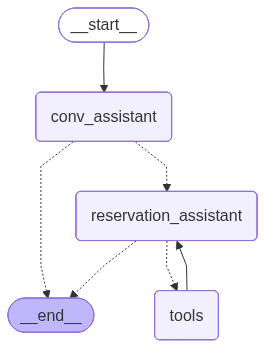

In [ ]:
# Draw the graph
from IPython.display import Image, display
png = react_graph_with_memory.get_graph().draw_mermaid_png()
display(Image(png))

In [ ]:
from langchain_core.messages import HumanMessage

thread_id = 42

# let's put everything in a chat format

def chat_with_agent(react_graph_with_memory, thread_id):
  """
  Chat with the agent.

  Args:
    react_graph_with_memory (): The graph with the agent.
    thread_id (int): The ID of the thread.
  """
  while True:
      user_input = input("You: ")
      if user_input.lower() in ["quit", "exit"]:
          break

      events = react_graph_with_memory.stream(
          input={"messages": [HumanMessage(content=user_input)]},
          config={"thread_id": thread_id},
          stream_mode="values",
      )

      for event in events:
          event["messages"][-1].pretty_print()
          message_content = event["messages"][-1].content
          if "Answer:" in message_content:
              final_answer = message_content.split("Answer:", 1)[1].strip()
              print(f"Agent: {final_answer}")

chat_with_agent(react_graph_with_memory, thread_id)

================================ Human Message =================================

Hey, I want to book a romm in your hotel
================================== Ai Message ==================================

Hello! I'd be happy to help you with your booking. Could you please provide me with the room type you're interested in and the dates you would like to stay?
================================ Human Message =================================

Family Suite, from 22nd of April 2025 to 26th of April
================================== Ai Message ==================================

Thank you for the details! I will forward your request to our reservation assistant to assist you with the booking of the Family Suite from April 22nd to April 26th, 2025. 

Please hold on for a moment. 

**Forwarding to reservation_assistant.**
================================== Ai Message ==================================
Tool Calls:
  sql_db_query (call_CLD0tCkeFeYVYqNHlbYALq85)
 Call ID: call_CLD0tCkeFeYVYqNHlb

## Agent 3: Implement Compliance Agent

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_chroma langchain_core langchain_community chromadb pypdf fpdf

In [ ]:
import sqlite3

from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import SystemMessage
from google.colab import userdata
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langgraph.prebuilt import ToolNode, tools_condition

#connect to SQLite DB
conn = sqlite3.connect('hotel.db')
cursor = conn.cursor()

# Create the rooms table
cursor.execute('''
CREATE TABLE IF NOT EXISTS rooms (
  room_number INTEGER PRIMARY KEY,
  room_type TEXT NOT NULL,
  price REAL NOT NULL,
  max_capacity INTEGER NOT NULL,
  amenities TEXT
)
''')

# Create the reservations table
cursor.execute('''
CREATE TABLE IF NOT EXISTS reservations (
  reservation_id INTEGER PRIMARY KEY AUTOINCREMENT,
  guest_name TEXT NOT NULL,
  room_number INTEGER NOT NULL,
  start_date DATE NOT NULL,
  end_date DATE NOT NULL,
  FOREIGN KEY (room_number) REFERENCES rooms(room_number)
)
''')


# Example data for rooms
rooms_data = [
  (101, 'Single', 100, 1, 'TV, Wi-Fi'),
  (102, 'Double', 150, 2, 'TV, Wi-Fi, Balcony'),
  (103, 'Suite', 250, 3, 'TV, Wi-Fi, Balcony, Jacuzzi'),
  (104, 'Deluxe', 200, 2, 'TV, Wi-Fi, Mini-bar'),
  (105, 'Family Suite', 300, 4, 'TV, Wi-Fi, Balcony, Kitchenette'),
  (106, 'Executive Suite', 350, 2, 'TV, Wi-Fi, Balcony, Jacuzzi, City View'),
  (107, 'Double', 150, 2, 'TV, Wi-Fi'),
  (108, 'Deluxe', 200, 2, 'TV, Wi-Fi, Balcony, Fireplace')
]

# Insert the data
cursor.executemany('INSERT OR IGNORE INTO rooms VALUES (?, ?, ?, ?, ?)', rooms_data)

reservations_data = [
    ('Alice Smith', 102, '2025-03-15', '2025-03-18'),
    ('Bob Johnson', 105, '2025-04-22', '2025-04-25'),
    ('Charlie Brown', 106, '2025-06-10', '2025-06-12')
]

# Insert the data
cursor.executemany('INSERT INTO reservations (guest_name, room_number, start_date, end_date) VALUES (?, ?, ?, ?)', reservations_data)

conn.commit()
conn.close()
print("Database initialized successfully.")

# initialize the memory saver
memory = MemorySaver()

# Create an instance of LLM of your choice
llm = ChatOpenAI(model="gpt-4o-mini", api_key=userdata.get('OPENAI_API_KEY'),
                      temperature=0)


# define our db as a set of sql tools
db = SQLDatabase.from_uri("sqlite:///hotel.db")
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
sql_tools = toolkit.get_tools()

Database initialized successfully.


In [ ]:
# write compliance rules to the file and read it back
with open('compliance.txt', 'w') as file:
    file.write('The system should refuse or redirect queries with:')
    file.write('Illegal requests (e.g., falsifying documents, fraudulent bookings).')
    file.write('Hate speech, harassment, or explicit threats toward individuals or groups.')
    file.write('Offensive, obscene, or otherwise harmful content.')
    file.write('Request of information about other guests. You cannot share there names or dates of stay')

with open('compliance.txt', 'r') as file:
    content = file.read()

In [ ]:
import chromadb
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

# Set up OpenAI embeddings
embedding_function = OpenAIEmbeddingFunction(
    api_key=userdata.get('OPENAI_API_KEY'),
    model_name="text-embedding-ada-002"  # OpenAI's ada embeddings
)

# Initialize Chroma client with OpenAI embedding function
client = chromadb.Client()
collection = client.create_collection(
    name="compliance_rules",
    embedding_function=embedding_function
)

# Add documents to Chroma DB
collection.add(
    documents=[content],
    ids=["compliance_rules"]
)

In [ ]:
from langchain_chroma import Chroma
from langchain_openai.embeddings import OpenAIEmbeddings

# Set up OpenAI embeddings
openai_embeddings = OpenAIEmbeddings(model="text-embedding-ada-002", openai_api_key=userdata.get('OPENAI_API_KEY'))

# Connect LangChain with your Chroma collection
vectorstore = Chroma(
    client=client,
    collection_name="compliance_rules",
    embedding_function=openai_embeddings
)

In [ ]:
from langchain_core.tools import tool

# create a custom tool
@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query."""
    retrieved_docs = vectorstore.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

rag_tools = [retrieve]

In [ ]:
# bind LLM with tools
llm_with_sql_tools = llm.bind_tools(tools=sql_tools)
llm_with_rag_tools = llm.bind_tools(tools=rag_tools)


# System message for conversational agent
sys_msg_conversation = SystemMessage(content="""

  Role: You are the Conversation Coordinator for a hotel chain’s customer support system. Your role is to manage the flow of the conversation with the guest and decide whether to handle the request yourself or forward the conversation to the next agent based on the user’s needs.

  Primary Tasks:

  Engage with the user: Start the conversation politely and ask how you can assist them.
  Identify the nature of the request: Listen to the guest’s inquiry and determine if it’s a general question, booking-related, issue resolution, or any other category that might require specialized handling.
  Route the conversation if necessary: If the request requires expertise outside your scope, forward it to a specialized agent by answering with the name of the corresponding agent. There are the following agents available:

  - reservation_assistant;
  - compliance_checker.

  Maintain a friendly and helpful tone: Always aim for a customer-friendly and empathetic response. Ensure the guest feels heard and cared for.

  Guidelines:

  - First you need to forward every query to compliance checker. If it violates any rule then do not respond, otherwise respond yourself or forward the query to the next agent.
  - For general inquiries (e.g., facilities, amenities, location details), assist the user directly.
  - If user wants to book a room. The following information: room type, required dates. Only if user has provided this information forward to the reservation_assistant otherwise do not mention reservation_assistant.
   """)

# System message for sql-based reservation agent
sys_msg_sql = SystemMessage(content="""

  You are AI assistant specialized in SQL. You have access to the following database schema:

  Table: rooms
    room_number (INTEGER PRIMARY KEY)
    room_type (TEXT NOT NULL)
    price (REAL NOT NULL)
    max_capacity (INTEGER NOT NULL)
    amenities (TEXT)

  Table: reservations
    reservation_id (INTEGER PRIMARY KEY AUTOINCREMENT)
    guest_name (TEXT NOT NULL)
    room_number (INTEGER NOT NULL, FOREIGN KEY REFERENCES rooms(room_number))
    start_date (DATE NOT NULL)
    end_date (DATE NOT NULL)

  You must:
    Provide SQL queries or instructions referencing only these two tables and the columns defined above.
    Generate valid SQL statements that accurately address the user’s questions or requests.
    Include explanations about how the queries work or how they address the request.
    Use best practices for SQL (proper joins, filters, etc.).
    Do not reference any tables or columns other than rooms and reservations.
    If the user’s request is unclear or not possible with the given schema, ask for clarification or note the limitations.
    If user want to book a room check if the room is not already booked for the corresponding dates

   """)

# System message for rag-based compliance checker
sys_msg_rag = SystemMessage(content=f"""

  You are the Compliance Checker agent. Your role is to:
  - Understand the user’s request and determine which rules, regulations, or guidelines are relevant to the query.
  - Search a vector database (embedding-based document retrieval) to find the most pertinent guidelines or regulations that must be checked.

      You have read-only access to this vector database containing short texts, summaries, or entire regulations.
      You can pass a query (the user’s question, plus any relevant context) to retrieve the top related guidelines or rules.
  - Synthesize the results of your vector DB retrieval to provide a clear compliance assessment or recommendation.
      If the user’s question is ambiguous, incomplete, or requires additional detail to ensure compliance, politely request clarification.
      If no relevant guidelines can be found, state that no matching guidelines are found and ask the user if they have additional info.
  - Never fabricate guidelines. Only cite or summarize what is actually found in the vector database. If you cannot find relevant information, say so.


  Please follow these steps when generating a response:
    - you should not try to answer the request you should just check if it is compliant.
    - Retrieve the relevant guidelines from the vector DB using the user’s question or text as the query.
    - Summarize or quote the most critical points from those guidelines.
    - Provide your compliance assessment, specifying:
      Which guidelines apply
    - If you cannot find any rules to apply it means that the request is compliant.

    \n\n
        {0}

   """)

# Agent node
def conv_assistant(state: MessagesState) -> MessagesState:
   """
   SQL Assistant Agent

   Args:
     state (MessagesState): The current state of the conversation.

   Returns:
     MessagesState: The updated state of the conversation.
   """
   messages = state["messages"]
   return {"messages": [llm.invoke([sys_msg_conversation] + messages)]}

# SQL Agent node
def sql_assistant(state: MessagesState) -> MessagesState:
  """
   SQL Assistant Agent

   Args:
     state (MessagesState): The current state of the conversation.

   Returns:
     MessagesState: The updated state of the conversation.
   """
  messages = state["messages"]
  return {"messages": [llm_with_sql_tools.invoke([sys_msg_sql] + messages)]}

# RAG Agent node
def rag_assistant(state: MessagesState) -> MessagesState:
  """
   RAG Assistant Agent

   Args:
     state (MessagesState): The current state of the conversation.

   Returns:
     MessagesState: The updated state of the conversation.
   """
  messages = state["messages"]
  return {"messages": [llm_with_rag_tools.invoke([sys_msg_rag] + messages)]}

#
def generate(state: MessagesState) -> MessagesState:
    """
    Node for answer generation based on retrieved documents.

    Args:
      state (MessagesState): The current state of the conversation.

    Returns:
      MessagesState: The updated state of the conversation.
    """
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    docs_content = "\n\n".join(doc.content for doc in tool_messages)

    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]

    # Run
    response = llm.invoke([sys_msg_rag] + conversation_messages)
    return {"messages": [response]}

def choose_next_node(state: MessagesState) -> Literal["reservation_assistant", "compliance_checker", "__end__"]:
  """
  Choose the next node based on the last message.

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    str: The name of the next node.
  """
  last_message = state["messages"][-1]
  if ("reservation_assistant" in last_message.content) or ("reservation assistant" in last_message.content):
    return "reservation_assistant"
  elif ("compliance_checker" in last_message.content) or ("compliance checker" in last_message.content):
    return "compliance_checker"
  else:
    return "__end__"


# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("conv_assistant", conv_assistant)
builder.add_node("reservation_assistant", sql_assistant)
builder.add_node("compliance_checker", rag_assistant)
builder.add_node("retriever", generate)
builder.add_node("sql_tools", ToolNode(sql_tools))
builder.add_node("rag_tools", ToolNode(rag_tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "conv_assistant")
builder.add_conditional_edges(
    "conv_assistant",
    # If the message from assistant is a tool call -> routes to tools
    #Otherwise to the END
    choose_next_node, path_map=["reservation_assistant", "compliance_checker", "__end__"])
builder.add_conditional_edges("reservation_assistant", tools_condition, path_map={"tools": "sql_tools", "__end__": "__end__"})
builder.add_conditional_edges("compliance_checker", tools_condition, path_map={"tools": "rag_tools", "__end__": "conv_assistant"})
builder.add_edge("sql_tools", "reservation_assistant")
builder.add_edge("rag_tools", "retriever")
builder.add_edge("retriever", "conv_assistant")
react_graph_with_memory = builder.compile(checkpointer=memory)


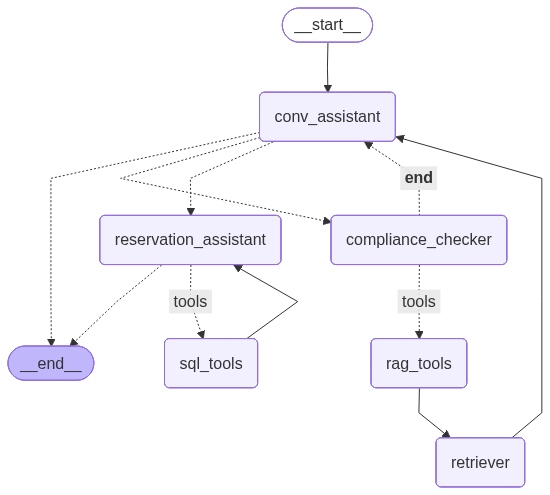

In [ ]:
# Draw the graph
from IPython.display import Image, display
png = react_graph_with_memory.get_graph().draw_mermaid_png()
display(Image(png))

In [ ]:
from langchain_core.messages import HumanMessage

thread_id = 42

# let's put everything in a chat format

def chat_with_agent(react_graph_with_memory, thread_id):
  """
  Chat with the agent.

  Args:
    react_graph_with_memory (): The graph with the agent.
    thread_id (int): The ID of the thread.
  """
  while True:
      user_input = input("You: ")
      if user_input.lower() in ["quit", "exit"]:
          break

      events = react_graph_with_memory.stream(
          input={"messages": [HumanMessage(content=user_input)]},
          config={"thread_id": thread_id},
          stream_mode="values",
      )

      for event in events:
          event["messages"][-1].pretty_print()
          message_content = event["messages"][-1].content
          if "Answer:" in message_content:
              final_answer = message_content.split("Answer:", 1)[1].strip()
              print(f"Agent: {final_answer}")

chat_with_agent(react_graph_with_memory, thread_id)

You: Hey, I want to book a Family Suite from 22.04.2025 till 26.04.2025
================================ Human Message =================================

Hey, I want to book a Family Suite from 22.04.2025 till 26.04.2025
================================== Ai Message ==================================

Let me first check with our compliance checker regarding your request. Please hold on for a moment. 

[Forwarding to compliance_checker...]
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_ypctT3DKqknyrzG5mptHCo0e)
 Call ID: call_ypctT3DKqknyrzG5mptHCo0e
  Args:
    query: booking a Family Suite from 22.04.2025 till 26.04.2025
================================= Tool Message =================================
Name: retrieve

Source: {}
Content: The system should refuse or redirect queries with:Illegal requests (e.g., falsifying documents, fraudulent bookings).Hate speech, harassment, or explicit threats toward individuals or groups

KeyboardInterrupt: Interrupted by user